In [ ]:
import pandas as pd
import glob


In [ ]:
# folder path
path = r"D:\egg_price_procject\output\main_data\*.csv"
# get all csv files
files = glob.glob(path)


In [ ]:
# getting all cities data in dic all_data
all_data = {}
for file in files:
    name = file.split("\\")[-1].split(".")[0]
    file_name = name
    name = pd.read_csv(file)
    all_data[file_name] = name
print(all_data.keys())


dict_keys(['Ajmer_main_data', 'Barwala_main_data', 'Delhi_main_data', 'Hyderabad_main_data', 'Indore_main_data', 'Varanasi_main_data'])


In [ ]:
all_data['Barwala_main_data'].head(20)


,Category,City,Price,Day,Month,Year,Date,daily_change_pct,market_rating,lag_1,...,quarter,is_weekend,lag_3,lag_14,lag_30,date,tmax,prcp,festival_name,is_festival
0,NECC SUGGESTED EGG PRICES,Barwala,375.0,11,5,2016,2016-05-11,NaN,0,NaN,...,2,0,NaN,NaN,NaN,2016-05-11,35.9,0.6,NaN,NaN
1,NECC SUGGESTED EGG PRICES,Barwala,375.0,12,5,2016,2016-05-12,0.000000,0,375.0,...,2,0,NaN,NaN,NaN,2016-05-12,37.3,0.0,NaN,NaN
2,NECC SUGGESTED EGG PRICES,Barwala,375.0,13,5,2016,2016-05-13,0.000000,0,375.0,...,2,0,NaN,NaN,NaN,2016-05-13,39.5,0.5,NaN,NaN
3,NECC SUGGESTED EGG PRICES,Barwala,378.0,14,5,2016,2016-05-14,0.800000,0,375.0,...,2,1,375.0,NaN,NaN,2016-05-14,40.9,0.0,NaN,NaN
4,NECC SUGGESTED EGG PRICES,Barwala,378.0,15,5,2016,2016-05-15,0.000000,0,378.0,...,2,1,375.0,NaN,NaN,2016-05-15,41.1,0.0,NaN,NaN
5,NECC SUGGESTED EGG PRICES,Barwala,378.0,16,5,2016,2016-05-16,0.000000,0,378.0,...,2,0,375.0,NaN,NaN,2016-05-16,41.3,0.2,NaN,NaN
6,NECC SUGGESTED EGG PRICES,Barwala,378.0,17,5,2016,2016-05-17,0.000000,0,378.0,...,2,0,378.0,NaN,NaN,2016-05-17,41.7,0.0,NaN,NaN
7,NECC SUGGESTED EGG PRICES,Barwala,361.0,18,5,2016,2016-05-18,-4.497354,-2,378.0,...,2,0,378.0,NaN,NaN,2016-05-18,42.8,0.0,NaN,NaN
8,NECC SUGGESTED EGG PRICES,Barwala,350.0,19,5,2016,2016-05-19,-3.047091,-2,361.0,...,2,0,378.0,NaN,NaN,2016-05-19,41.5,0.5,NaN,NaN
9,NECC SUGGESTED EGG PRICES,Barwala,350.0,20,5,2016,2016-05-20,0.000000,0,350.0,...,2,0,378.0,NaN,NaN,2016-05-20,41.3,0.0,NaN,NaN


### FOR NOW I AM JUST GETTING BARWALA DATA

In [ ]:
df = all_data['Barwala_main_data']


In [ ]:
df.head()


,Category,City,Price,Day,Month,Year,Date,daily_change_pct,market_rating,lag_1,...,quarter,is_weekend,lag_3,lag_14,lag_30,date,tmax,prcp,festival_name,is_festival
0,NECC SUGGESTED EGG PRICES,Barwala,375.0,11,5,2016,2016-05-11,NaN,0,NaN,...,2,0,NaN,NaN,NaN,2016-05-11,35.9,0.6,NaN,NaN
1,NECC SUGGESTED EGG PRICES,Barwala,375.0,12,5,2016,2016-05-12,0.0,0,375.0,...,2,0,NaN,NaN,NaN,2016-05-12,37.3,0.0,NaN,NaN
2,NECC SUGGESTED EGG PRICES,Barwala,375.0,13,5,2016,2016-05-13,0.0,0,375.0,...,2,0,NaN,NaN,NaN,2016-05-13,39.5,0.5,NaN,NaN
3,NECC SUGGESTED EGG PRICES,Barwala,378.0,14,5,2016,2016-05-14,0.8,0,375.0,...,2,1,375.0,NaN,NaN,2016-05-14,40.9,0.0,NaN,NaN
4,NECC SUGGESTED EGG PRICES,Barwala,378.0,15,5,2016,2016-05-15,0.0,0,378.0,...,2,1,375.0,NaN,NaN,2016-05-15,41.1,0.0,NaN,NaN


In [ ]:
df.columns


Index(['Category', 'City', 'Price', 'Day', 'Month', 'Year', 'Date',
       'daily_change_pct', 'market_rating', 'lag_1', 'lag_7', 'rolling_mean_7',
       'rolling_mean_14', 'rolling_mean_30', 'rolling_std_7', 'dayofweek',
       'weekofyear', 'quarter', 'is_weekend', 'lag_3', 'lag_14', 'lag_30',
       'date', 'tmax', 'prcp', 'festival_name', 'is_festival'],
      dtype='object')

In [ ]:
df = df.drop(['festival_name','City','Category'], axis=1)
df['is_festival'] = df['is_festival'].notna().astype(int)


In [ ]:
# df = df.dropna()


In [ ]:
df.head()


,Price,Day,Month,Year,Date,daily_change_pct,market_rating,lag_1,lag_7,rolling_mean_7,...,weekofyear,quarter,is_weekend,lag_3,lag_14,lag_30,date,tmax,prcp,is_festival
0,375.0,11,5,2016,2016-05-11,NaN,0,NaN,NaN,NaN,...,19,2,0,NaN,NaN,NaN,2016-05-11,35.9,0.6,0
1,375.0,12,5,2016,2016-05-12,0.0,0,375.0,NaN,NaN,...,19,2,0,NaN,NaN,NaN,2016-05-12,37.3,0.0,0
2,375.0,13,5,2016,2016-05-13,0.0,0,375.0,NaN,NaN,...,19,2,0,NaN,NaN,NaN,2016-05-13,39.5,0.5,0
3,378.0,14,5,2016,2016-05-14,0.8,0,375.0,NaN,NaN,...,19,2,1,375.0,NaN,NaN,2016-05-14,40.9,0.0,0
4,378.0,15,5,2016,2016-05-15,0.0,0,378.0,NaN,NaN,...,19,2,1,375.0,NaN,NaN,2016-05-15,41.1,0.0,0


In [ ]:
df.shape


(3616, 24)

In [ ]:
df['is_festival'].unique()


array([0, 1])

In [ ]:
df['is_festival'].value_counts()


0    3457
1     159
Name: is_festival, dtype: int64

In [ ]:
df.shape


(3616, 24)

In [ ]:
df.isnull().sum()


Price                0
Day                  0
Month                0
Year                 0
Date                 0
daily_change_pct     1
market_rating        0
lag_1                1
lag_7                7
rolling_mean_7       7
rolling_mean_14     14
rolling_mean_30     30
rolling_std_7        7
dayofweek            0
weekofyear           0
quarter              0
is_weekend           0
lag_3                3
lag_14              14
lag_30              30
date                 0
tmax                 0
prcp                 0
is_festival          0
dtype: int64

In [ ]:
df =df.dropna()


In [ ]:
df.shape


(3586, 24)

In [ ]:
df.head()


,Price,Day,Month,Year,Date,daily_change_pct,market_rating,lag_1,lag_7,rolling_mean_7,...,weekofyear,quarter,is_weekend,lag_3,lag_14,lag_30,date,tmax,prcp,is_festival
30,360.0,10,6,2016,2016-06-10,0.558659,0,358.0,348.0,354.000000,...,23,2,0,356.0,348.0,375.0,2016-06-10,39.9,0.3,0
31,360.0,11,6,2016,2016-06-11,0.000000,0,360.0,352.0,355.714286,...,23,2,1,358.0,330.0,375.0,2016-06-11,37.8,0.5,0
32,360.0,12,6,2016,2016-06-12,0.000000,0,360.0,352.0,356.857143,...,23,2,1,358.0,333.0,375.0,2016-06-12,38.8,0.0,0
33,367.0,13,6,2016,2016-06-13,1.944444,1,360.0,354.0,358.000000,...,24,2,0,360.0,339.0,378.0,2016-06-13,40.1,0.3,0
34,373.0,14,6,2016,2016-06-14,1.634877,1,367.0,356.0,359.857143,...,24,2,0,360.0,348.0,378.0,2016-06-14,37.5,2.0,0


In [ ]:
df.head()


,Price,Day,Month,Year,Date,daily_change_pct,market_rating,lag_1,lag_7,rolling_mean_7,...,weekofyear,quarter,is_weekend,lag_3,lag_14,lag_30,date,tmax,prcp,is_festival
30,360.0,10,6,2016,2016-06-10,0.558659,0,358.0,348.0,354.000000,...,23,2,0,356.0,348.0,375.0,2016-06-10,39.9,0.3,0
31,360.0,11,6,2016,2016-06-11,0.000000,0,360.0,352.0,355.714286,...,23,2,1,358.0,330.0,375.0,2016-06-11,37.8,0.5,0
32,360.0,12,6,2016,2016-06-12,0.000000,0,360.0,352.0,356.857143,...,23,2,1,358.0,333.0,375.0,2016-06-12,38.8,0.0,0
33,367.0,13,6,2016,2016-06-13,1.944444,1,360.0,354.0,358.000000,...,24,2,0,360.0,339.0,378.0,2016-06-13,40.1,0.3,0
34,373.0,14,6,2016,2016-06-14,1.634877,1,367.0,356.0,359.857143,...,24,2,0,360.0,348.0,378.0,2016-06-14,37.5,2.0,0


In [ ]:
df.dtypes


Price               float64
Day                   int64
Month                 int64
Year                  int64
Date                 object
daily_change_pct    float64
market_rating         int64
lag_1               float64
lag_7               float64
rolling_mean_7      float64
rolling_mean_14     float64
rolling_mean_30     float64
rolling_std_7       float64
dayofweek             int64
weekofyear            int64
quarter               int64
is_weekend            int64
lag_3               float64
lag_14              float64
lag_30              float64
date                 object
tmax                float64
prcp                float64
is_festival           int32
dtype: object

### XGBoost time-series model

The rows are sorted by date before splitting. The model is tuned only on past training data with `TimeSeriesSplit`, then evaluated on the 2025 holdout period.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
except ImportError as exc:
    raise ImportError(
        "XGBoost is required for this notebook. Install it with: pip install xgboost"
    ) from exc


In [ ]:
# features = [
#     "market_rating", "lag_1", "lag_3", "lag_7", "lag_14", "lag_30",
#     "rolling_mean_7", "rolling_mean_14", "rolling_mean_30", "rolling_std_7",
#     "tmax", "prcp", "dayofweek", "weekofyear", "quarter",
#     "is_weekend", "is_festival"
# ]

In [ ]:
# Keep the time order explicit for forecasting-style evaluation.
df_model = df.copy()
df_model["Date"] = pd.to_datetime(df_model["Date"])
df_model = df_model.sort_values("Date").reset_index(drop=True)

features = [
    "market_rating","lag_3", "lag_7", "lag_14", "lag_30",
    "rolling_mean_7", "rolling_mean_14", "rolling_mean_30", "rolling_std_7",
    "tmax", "prcp", "dayofweek", "weekofyear", "quarter",
    "is_weekend", "is_festival"
]
target = "Price"

model_columns = ["Date", target] + features
df_model = df_model[model_columns].dropna().reset_index(drop=True)

train_data = df_model[df_model["Date"].dt.year < 2025].copy()
test_data = df_model[df_model["Date"].dt.year == 2025].copy()

x_train = train_data[features]
y_train = train_data[target]
x_test = test_data[features]
y_test = test_data[target]

print(f"Train period: {train_data['Date'].min().date()} to {train_data['Date'].max().date()} | rows: {len(train_data)}")
print(f"Test period:  {test_data['Date'].min().date()} to {test_data['Date'].max().date()} | rows: {len(test_data)}")


Train period: 2016-06-10 to 2024-12-31 | rows: 3090
Test period:  2025-01-01 to 2025-12-31 | rows: 365


In [ ]:
# Tune hyperparameters with time-series aware cross-validation.
# RandomizedSearchCV is faster than a full grid while still testing strong parameter combinations.
tscv = TimeSeriesSplit(n_splits=5)

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

param_distributions = {
    "n_estimators": [300, 500, 800, 1000],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "reg_alpha": [0, 0.01, 0.05, 0.1],
    "reg_lambda": [0.5, 1, 2, 5],
    "gamma": [0, 0.01, 0.05, 0.1]
}

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=60,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(x_train, y_train)

best_model = search.best_estimator_
print("Best CV RMSE:", round(-search.best_score_, 3))
print("Best parameters:")
search.best_params_


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best CV RMSE: 19.085
Best parameters:


{'subsample': 0.8,
 'reg_lambda': 0.5,
 'reg_alpha': 0.01,
 'n_estimators': 300,
 'min_child_weight': 3,
 'max_depth': 3,
 'learning_rate': 0.08,
 'gamma': 0.01,
 'colsample_bytree': 1.0}

In [ ]:
# Predict on the untouched 2025 test period.
test_results = test_data[["Date", target]].copy()
test_results["Predicted_Price"] = best_model.predict(x_test)
test_results["Error"] = test_results[target] - test_results["Predicted_Price"]
test_results["Absolute_Error"] = test_results["Error"].abs()

mae = mean_absolute_error(y_test, test_results["Predicted_Price"])
rmse = root_mean_squared_error(y_test, test_results["Predicted_Price"])
r2 = r2_score(y_test, test_results["Predicted_Price"])
mape = np.mean(np.abs(test_results["Error"] / y_test)) * 100

metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2", "MAPE (%)"],
    "Value": [mae, rmse, r2, mape]
})
metrics["Value"] = metrics["Value"].round(3)

print(f"Mean absolute error: {mae:.2f} price points")
print(f"Root mean squared error: {rmse:.2f} price points")
print(f"R2 score: {r2:.3f}")
print(f"Mean absolute percentage error: {mape:.2f}%")
metrics


Mean absolute error: 14.23 price points
Root mean squared error: 22.53 price points
R2 score: 0.931
Mean absolute percentage error: 2.62%


,Metric,Value
0,MAE,14.230
1,RMSE,22.526
2,R2,0.931
3,MAPE (%),2.619


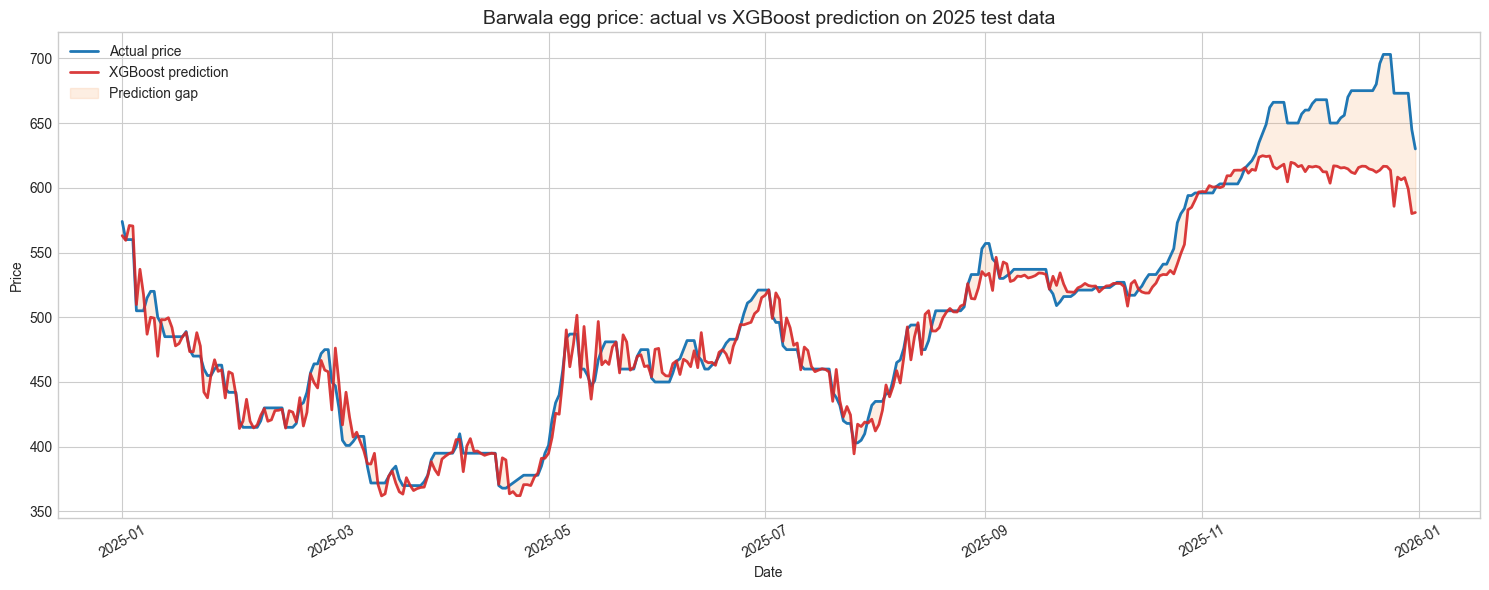

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(test_results["Date"], test_results[target], label="Actual price", color="#1f77b4", linewidth=2)
ax.plot(test_results["Date"], test_results["Predicted_Price"], label="XGBoost prediction", color="#d62728", linewidth=2, alpha=0.9)
ax.fill_between(
    test_results["Date"],
    test_results[target],
    test_results["Predicted_Price"],
    color="#f4a261",
    alpha=0.18,
    label="Prediction gap"
)

ax.set_title("Barwala egg price: actual vs XGBoost prediction on 2025 test data", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


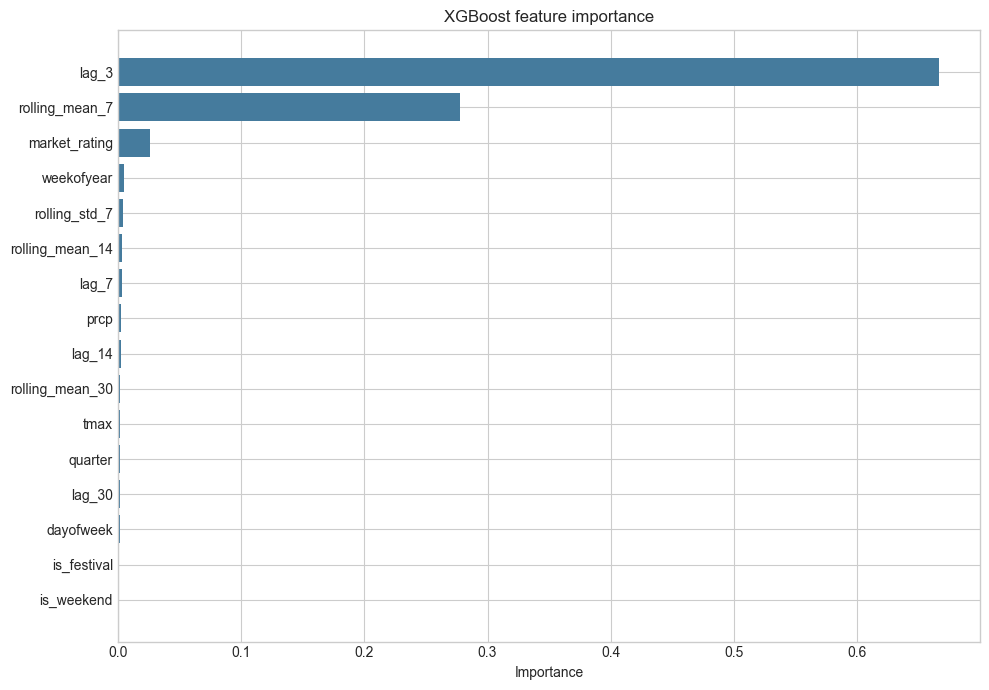

,Feature,Importance
1,lag_3,0.666375
5,rolling_mean_7,0.277565
0,market_rating,0.025843
12,weekofyear,0.005103
8,rolling_std_7,0.003976
6,rolling_mean_14,0.003498
2,lag_7,0.003038
10,prcp,0.002540
3,lag_14,0.002412
7,rolling_mean_30,0.001853


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(feature_importance["Feature"], feature_importance["Importance"], color="#457b9d")
ax.set_title("XGBoost feature importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

feature_importance.sort_values("Importance", ascending=False).head(10)


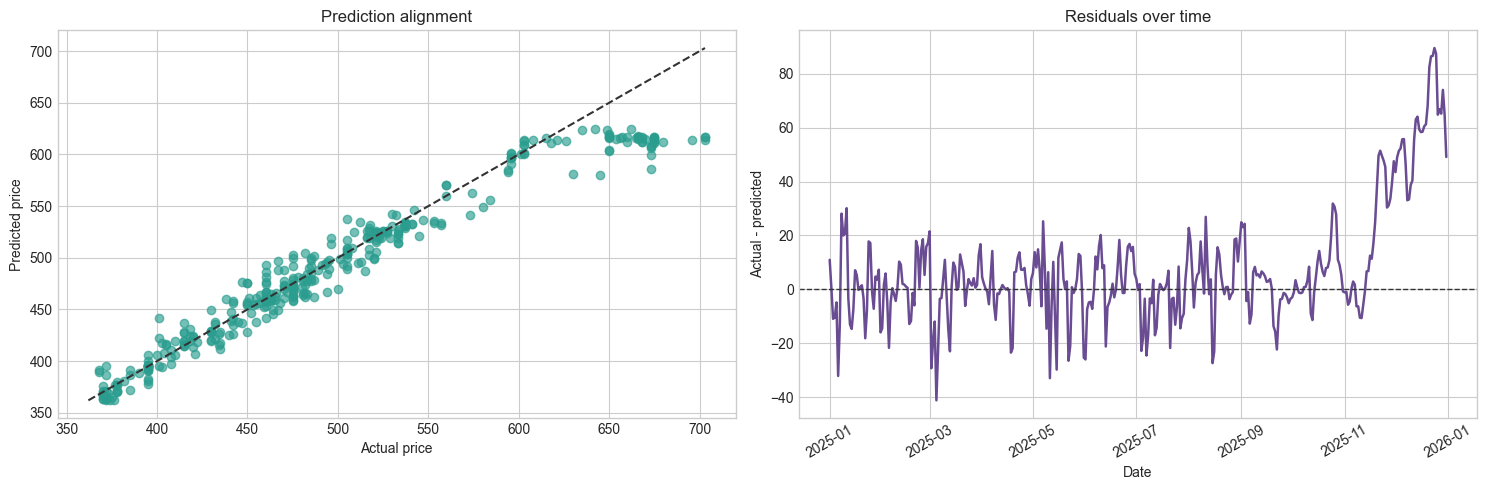

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(test_results[target], test_results["Predicted_Price"], alpha=0.65, color="#2a9d8f")
min_price = min(test_results[target].min(), test_results["Predicted_Price"].min())
max_price = max(test_results[target].max(), test_results["Predicted_Price"].max())
axes[0].plot([min_price, max_price], [min_price, max_price], color="#333333", linestyle="--", linewidth=1.5)
axes[0].set_title("Prediction alignment")
axes[0].set_xlabel("Actual price")
axes[0].set_ylabel("Predicted price")

axes[1].plot(test_results["Date"], test_results["Error"], color="#6a4c93", linewidth=1.8)
axes[1].axhline(0, color="#333333", linestyle="--", linewidth=1)
axes[1].set_title("Residuals over time")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Actual - predicted")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


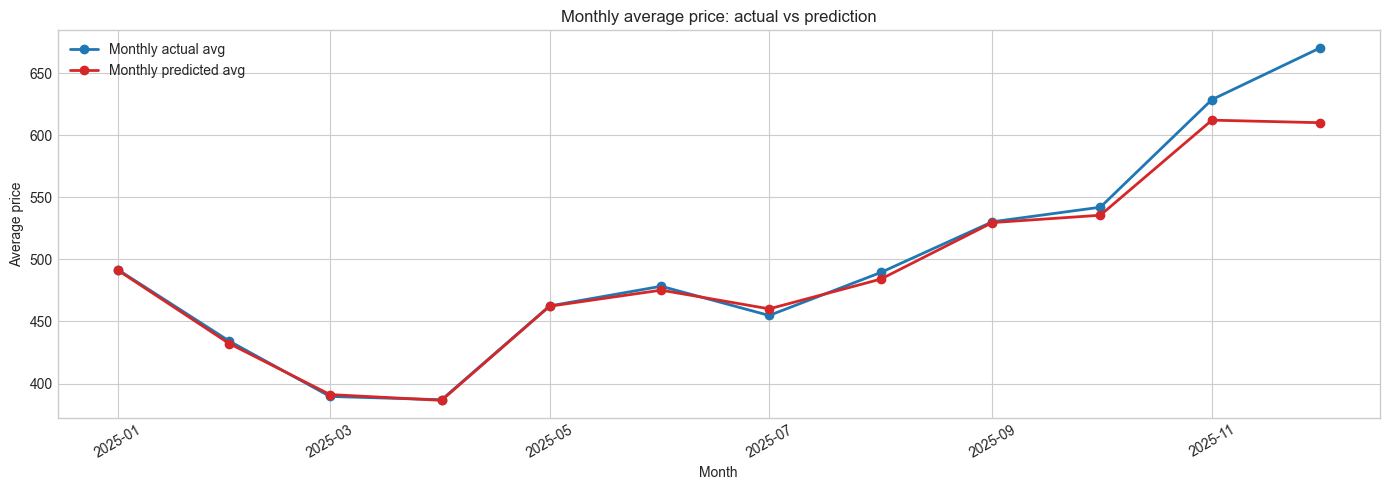

,Month,Actual_Price,Predicted_Price,Mean_Absolute_Error
0,2025-01-01,491.81,491.359985,10.90
1,2025-02-01,434.18,432.190002,7.95
2,2025-03-01,389.58,391.089996,9.87
3,2025-04-01,386.93,386.440002,5.84
4,2025-05-01,462.48,462.260010,11.47
5,2025-06-01,478.33,475.200012,9.17
6,2025-07-01,454.81,460.130005,8.21
7,2025-08-01,489.42,484.079987,9.77
8,2025-09-01,530.27,529.619995,7.99
9,2025-10-01,542.00,535.539978,8.39


In [ ]:
# Monthly view: compare average actual and predicted prices.
monthly_results = (
    test_results
    .assign(Month=test_results["Date"].dt.to_period("M").dt.to_timestamp())
    .groupby("Month", as_index=False)
    .agg(
        Actual_Price=(target, "mean"),
        Predicted_Price=("Predicted_Price", "mean"),
        Mean_Absolute_Error=("Absolute_Error", "mean")
    )
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_results["Month"], monthly_results["Actual_Price"], marker="o", label="Monthly actual avg", color="#1f77b4", linewidth=2)
ax.plot(monthly_results["Month"], monthly_results["Predicted_Price"], marker="o", label="Monthly predicted avg", color="#d62728", linewidth=2)
ax.set_title("Monthly average price: actual vs prediction")
ax.set_xlabel("Month")
ax.set_ylabel("Average price")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

monthly_results.round(2)


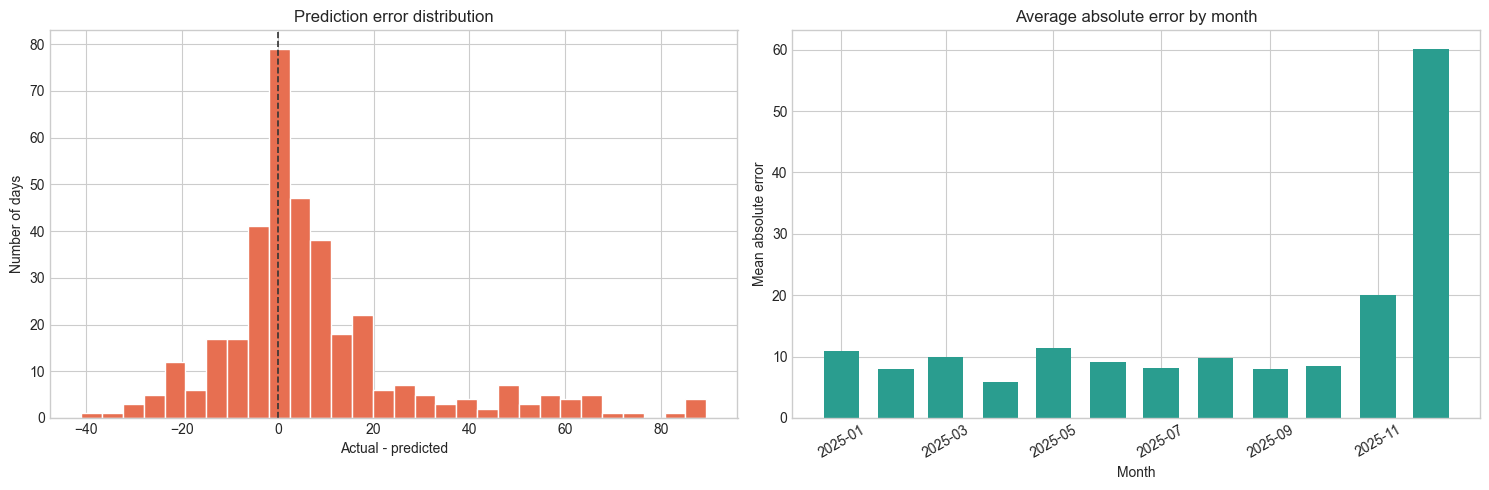

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(test_results["Error"], bins=30, color="#e76f51", edgecolor="white")
axes[0].axvline(0, color="#333333", linestyle="--", linewidth=1.2)
axes[0].set_title("Prediction error distribution")
axes[0].set_xlabel("Actual - predicted")
axes[0].set_ylabel("Number of days")

axes[1].bar(monthly_results["Month"], monthly_results["Mean_Absolute_Error"], width=20, color="#2a9d8f")
axes[1].set_title("Average absolute error by month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Mean absolute error")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


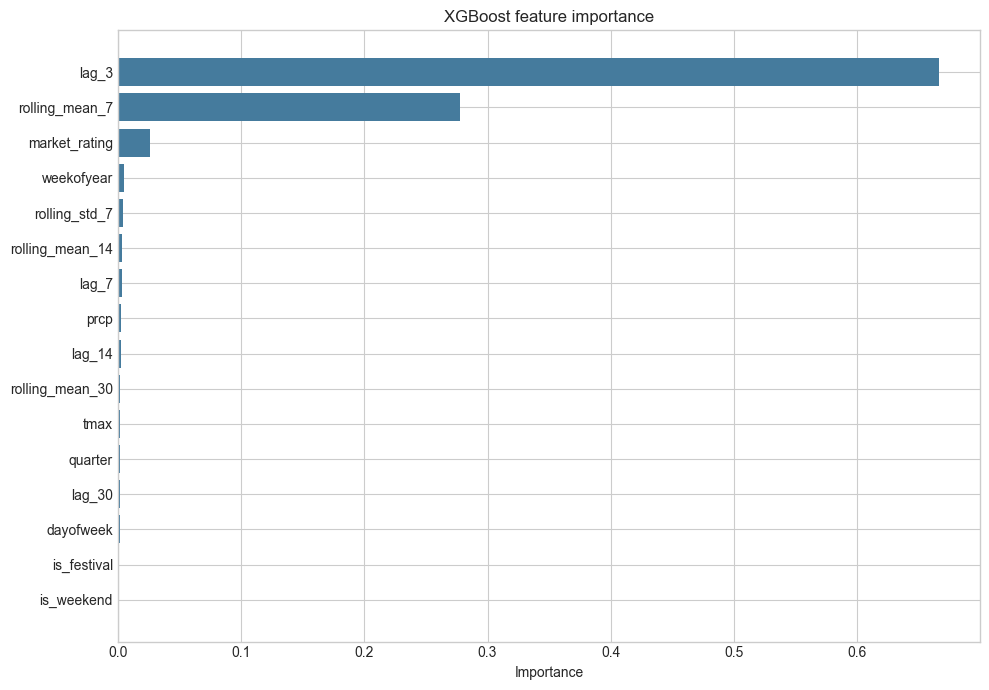

,Feature,Importance
1,lag_3,0.666375
5,rolling_mean_7,0.277565
0,market_rating,0.025843
12,weekofyear,0.005103
8,rolling_std_7,0.003976
6,rolling_mean_14,0.003498
2,lag_7,0.003038
10,prcp,0.002540
3,lag_14,0.002412
7,rolling_mean_30,0.001853


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(feature_importance["Feature"], feature_importance["Importance"], color="#457b9d")
ax.set_title("XGBoost feature importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

feature_importance.sort_values("Importance", ascending=False).head(10)


In [ ]:
# Quick view of the days with the largest misses.
test_results.sort_values("Absolute_Error", ascending=False).head(10)


,Date,Price,Predicted_Price,Error,Absolute_Error
3447,2025-12-24,703.0,613.521973,89.478027,89.478027
3448,2025-12-25,673.0,585.695312,87.304688,87.304688
3446,2025-12-23,703.0,616.445923,86.554077,86.554077
3445,2025-12-22,703.0,616.597290,86.402710,86.402710
3444,2025-12-21,696.0,613.624084,82.375916,82.375916
3452,2025-12-29,673.0,599.038391,73.961609,73.961609
3443,2025-12-20,680.0,611.961487,68.038513,68.038513
3450,2025-12-27,673.0,606.148193,66.851807,66.851807
3451,2025-12-28,673.0,607.850403,65.149597,65.149597
3453,2025-12-30,645.0,580.082092,64.917908,64.917908
